In [1]:
# Import libraries

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [2]:
# Load MRI image and brain mask from MATLAB v7.3 file using h5py

import h5py

file = h5py.File("data/assignmentSegmentBrain.mat", 'r')

print(list(file.keys()))

['imageData', 'imageMask']


In [3]:
# Extract MRI image and mask

Y = np.array(file['imageData']).T
mask = np.array(file['imageMask']).T
Y = Y / np.max(Y)
Y = Y.astype(np.float64)
mask = mask.astype(bool)
Y[~mask] = 0

(-0.5, 255.5, 255.5, -0.5)

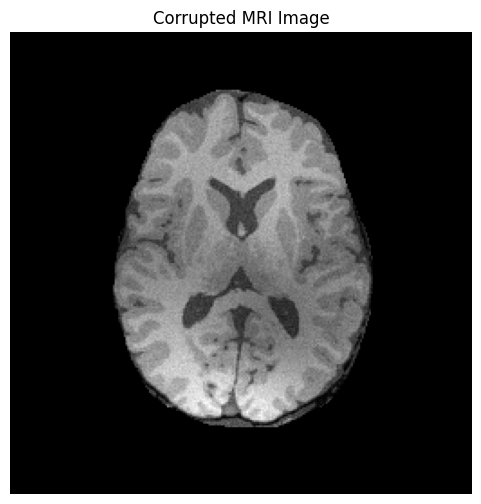

In [4]:
# Display corrupted MRI image

plt.figure(figsize=(6,6))
plt.imshow(Y, cmap='gray')
plt.title("Corrupted MRI Image")
plt.axis('off')

In [5]:
# Define algorithm parameters

K = 3           # number of classes
q = 1.6        # fuzziness parameter (>1.5)

max_iter = 50
eps = 1e-5

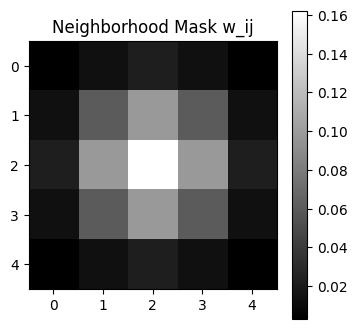

In [6]:
# Create Gaussian neighborhood mask w_ij

size = 5
sigma = 1.0

ax = np.arange(-(size//2), size//2+1)
xx, yy = np.meshgrid(ax, ax)

w = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
w = w / np.sum(w)

plt.figure(figsize=(4,4))
plt.imshow(w, cmap='gray')
plt.title("Neighborhood Mask w_ij")
plt.colorbar()

In [7]:
# Initialize membership values using intensity based clustering

brain_pixels = Y[mask]

percentiles = np.percentile(brain_pixels,[33,66])

c_init = np.array([
    np.mean(brain_pixels[brain_pixels<=percentiles[0]]),
    np.mean(brain_pixels[(brain_pixels>percentiles[0]) & (brain_pixels<=percentiles[1])]),
    np.mean(brain_pixels[brain_pixels>percentiles[1]])
])

U = np.zeros((K,*Y.shape))

for k in range(K):
    U[k] = np.random.rand(*Y.shape)


U = U / np.sum(U,axis=0)

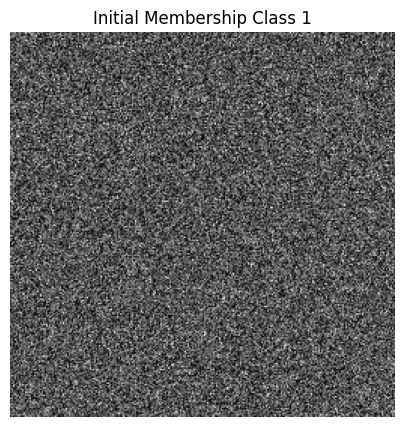

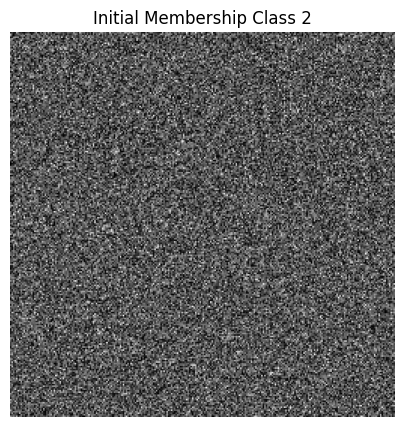

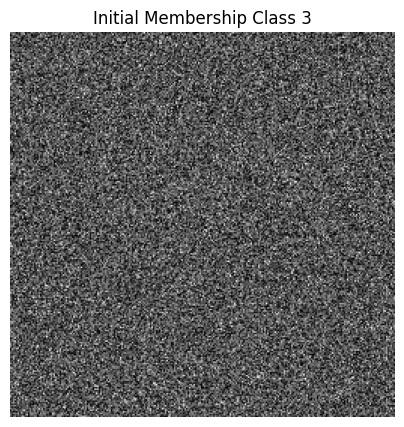

In [8]:
# Display initial memberships

for k in range(K):
    plt.figure(figsize=(5,5))
    plt.imshow(U[k], cmap='gray')
    plt.title(f"Initial Membership Class {k+1}")
    plt.axis('off')

In [9]:
# Initialize class means

c = c_init.copy()

print("Initial class means:", c)

Initial class means: [0.2141547  0.33627311 0.43976835]


In [10]:
# Initialize bias field as constant image

b = np.ones_like(Y)

In [11]:
# Function to compute neighborhood weighted intensity

from scipy.signal import convolve2d

def neighborhood_sum(image):
    return convolve2d(image, w, mode='same', boundary='symm')

In [12]:
# Compute distance term D_nk

def compute_distance(Y,b,c):

    D = np.zeros((K,*Y.shape))

    for k in range(K):
        diff = (Y - b*c[k])**2 + 1e-8
        D[k] = neighborhood_sum(diff)

    return D

In [13]:
# Update memberships
def update_membership(D,q):

    U = np.zeros_like(D)

    for k in range(K):

        denom = np.zeros_like(D[0])

        for l in range(K):

            ratio = (D[k] + 1e-8)/(D[l] + 1e-8)
            denom += ratio**(1/(q-1))

        U[k] = 1/(denom + 1e-8)

    # enforce fuzzy constraint
    U = U / np.sum(U,axis=0)

    return U

In [14]:
#Update the class means
def update_class_means(Y,U,b,q):

    c = np.zeros(K)

    for k in range(K):

        num = np.sum((U[k]**q) * Y * b * mask)
        den = np.sum((U[k]**q) * (b**2) * mask)

        c[k] = num/(den+1e-8)

    return c

In [15]:
# Update bias field

def update_bias(Y,U,c,q):

    num = np.zeros_like(Y)
    den = np.zeros_like(Y)

    for k in range(K):
        num += (U[k]**q) * c[k] * Y
        den += (U[k]**q) * (c[k]**2)

    b = num / (den + 1e-8)

    b = gaussian_filter(b, sigma=5)
    b = np.clip(b,0.5,1.5)
    return b

In [16]:
# Compute objective function

def objective_function(Y,U,b,c,q):

    J = 0

    for k in range(K):

        diff = (Y - b*c[k])**2 * mask
        D = neighborhood_sum(diff)

        J += np.sum((U[k]**q)*D*mask)

    return J

In [17]:
# Run modified FCM optimization

J_values = []

for it in range(max_iter):

    D = compute_distance(Y,b,c)

    U = update_membership(D,q)

    U[:,~mask] = 0

    U = U / (np.sum(U,axis=0) + 1e-8)
    c = update_class_means(Y,U,b,q)

    b = update_bias(Y,U,c,q)
    b = b / np.mean(b[mask])

    J = objective_function(Y,U,b,c,q)

    J_values.append(J)

    print("Iter",it,"J=",J)

    if it>2 and abs(J_values[-1]-J_values[-2])<eps:
        break

Iter 0 J= 66.22890836565001
Iter 1 J= 52.76171318192675
Iter 2 J= 49.779923060805515
Iter 3 J= 49.168621863682375
Iter 4 J= 49.099214212375045
Iter 5 J= 49.12061198418425
Iter 6 J= 49.18233207259488
Iter 7 J= 49.270448916235395
Iter 8 J= 49.35899724930492
Iter 9 J= 49.4760822106047
Iter 10 J= 49.6152661116881
Iter 11 J= 49.74463594079117
Iter 12 J= 49.870396225427456
Iter 13 J= 49.955287319037566
Iter 14 J= 49.96950732335909
Iter 15 J= 50.05142915301823
Iter 16 J= 50.18448190412152
Iter 17 J= 50.31390351310748
Iter 18 J= 50.43964631281938
Iter 19 J= 50.56343133664775
Iter 20 J= 50.67672041690229
Iter 21 J= 50.77557967935157
Iter 22 J= 50.86092204825358
Iter 23 J= 50.934769687958536
Iter 24 J= 50.9987160011881
Iter 25 J= 51.05426006365883
Iter 26 J= 51.102829362484016
Iter 27 J= 51.1459425274745
Iter 28 J= 51.18458007016309
Iter 29 J= 51.21710882782138
Iter 30 J= 51.236085961433304
Iter 31 J= 51.235348718383705
Iter 32 J= 51.21302715723708
Iter 33 J= 51.19036138019804
Iter 34 J= 51.1779

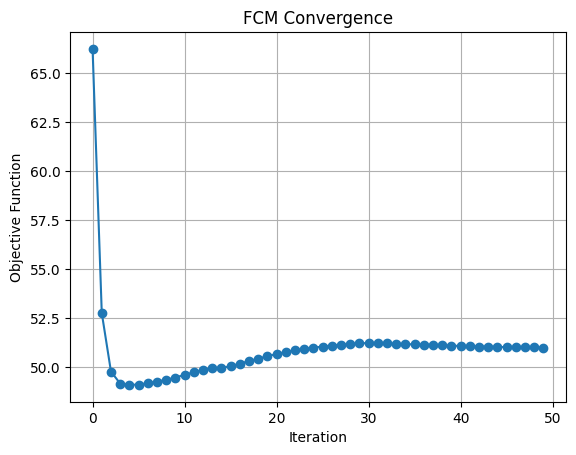

In [18]:
# Plot objective function vs iteration

plt.figure()
plt.plot(J_values,'-o')
plt.xlabel("Iteration")
plt.ylabel("Objective Function")
plt.title("FCM Convergence")
plt.grid()

In [19]:
# Compute bias removed image A

A = np.zeros_like(Y)

for k in range(K):
    A += U[k]*c[k]

In [20]:
# Compute residual image R

R = Y - A*b

In [21]:
# Compute final segmentation

seg = np.argmax(U,axis=0)

(-0.5, 255.5, 255.5, -0.5)

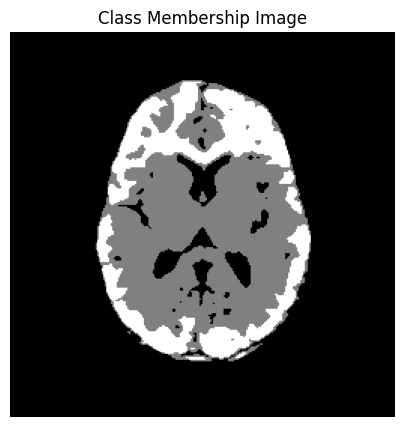

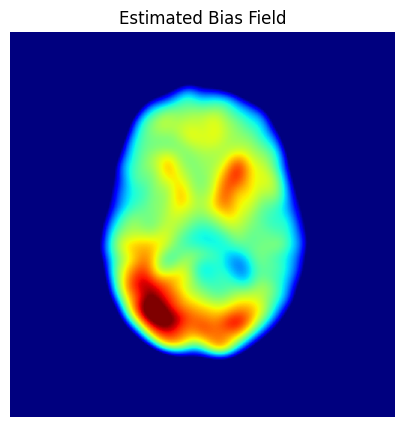

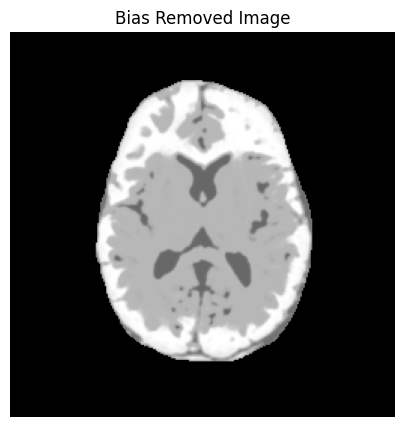

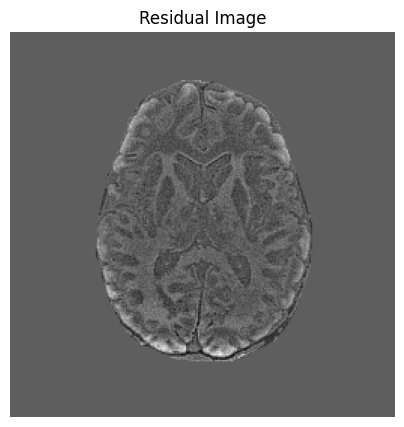

In [22]:
# Display results

plt.figure(figsize=(5,5))
plt.imshow(seg,cmap='gray')
plt.title("Class Membership Image")
plt.axis('off')

plt.figure(figsize=(5,5))
plt.imshow(b,cmap='jet')
plt.title("Estimated Bias Field")
plt.axis('off')

plt.figure(figsize=(5,5))
plt.imshow(A,cmap='gray')
plt.title("Bias Removed Image")
plt.axis('off')

plt.figure(figsize=(5,5))
plt.imshow(R,cmap='gray')
plt.title("Residual Image")
plt.axis('off')

In [23]:
# Print optimal class means

print("Optimal class means:",c)

Optimal class means: [0.176944   0.31241596 0.43671368]
